In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

plt.style.use("ggplot")

Read a Sample for Exploration

In [31]:
sample_df = pd.read_csv(
    "../data/raw/complaints.csv",
    nrows=50000,
    low_memory=False
)

print(sample_df.shape)
sample_df.head()

(50000, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


Check Products

In [32]:
sample_df["Product"].value_counts()

Product
Credit reporting or other personal consumer reports        46253
Debt collection                                             2171
Credit card                                                  569
Checking or savings account                                  331
Money transfer, virtual currency, or money service           228
Mortgage                                                     122
Vehicle loan or lease                                        109
Student loan                                                 107
Payday loan, title loan, personal loan, or advance loan       68
Debt or credit management                                     24
Prepaid card                                                  18
Name: count, dtype: int64

Filter Products

In [33]:
target_products = [
    "Credit card",
    "Checking or savings account",
    "Money transfer, virtual currency, or money service",
    "Payday loan, title loan, personal loan, or advance loan"
]

filtered_sample = sample_df[
    sample_df["Product"].isin(target_products)
]

print(filtered_sample.shape)

filtered_sample["Product"].value_counts()

(1196, 18)


Product
Credit card                                                569
Checking or savings account                                331
Money transfer, virtual currency, or money service         228
Payday loan, title loan, personal loan, or advance loan     68
Name: count, dtype: int64

Check Missing Narratives

In [34]:
filtered_sample["Consumer complaint narrative"].isna().sum()

np.int64(1090)

Remove Empty Narratives

In [35]:
filtered_sample = filtered_sample[
    filtered_sample["Consumer complaint narrative"].notna()
]

print(filtered_sample.shape)

(106, 18)


Narrative Length Analysis

In [36]:
filtered_sample["word_count"] = (
    filtered_sample["Consumer complaint narrative"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

filtered_sample["word_count"].describe()

count    106.000000
mean     203.330189
std      128.861588
min       18.000000
25%      113.250000
50%      171.000000
75%      253.750000
max      729.000000
Name: word_count, dtype: float64

Visualization 1: Product Distribution

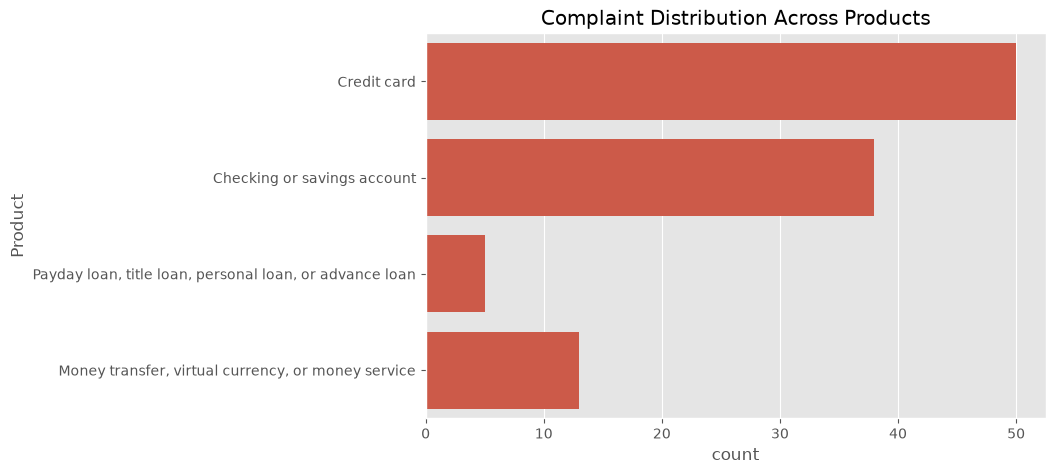

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=filtered_sample,
    y="Product"
)

plt.title("Complaint Distribution Across Products")
plt.show()

Visualization 2: Narrative Length

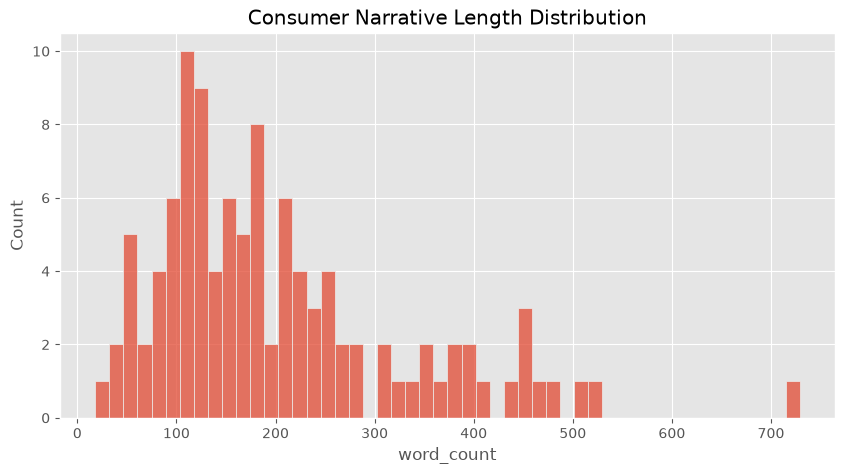

In [38]:
plt.figure(figsize=(10,5))

sns.histplot(
    filtered_sample["word_count"],
    bins=50
)

plt.title("Consumer Narrative Length Distribution")
plt.show()

Text Cleaning Function

In [39]:
import re

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

Apply:

In [40]:
filtered_sample["cleaned_narrative"] = (
    filtered_sample["Consumer complaint narrative"]
    .apply(clean_text)
)

In [41]:
filtered_sample.to_csv(
    "../data/processed/filtered_complaints.csv",
    index=False
)

print("Dataset saved successfully!")

OSError: Cannot save file into a non-existent directory: '..\data\processed'

2. Create EDA Visualizations


Product Distribution

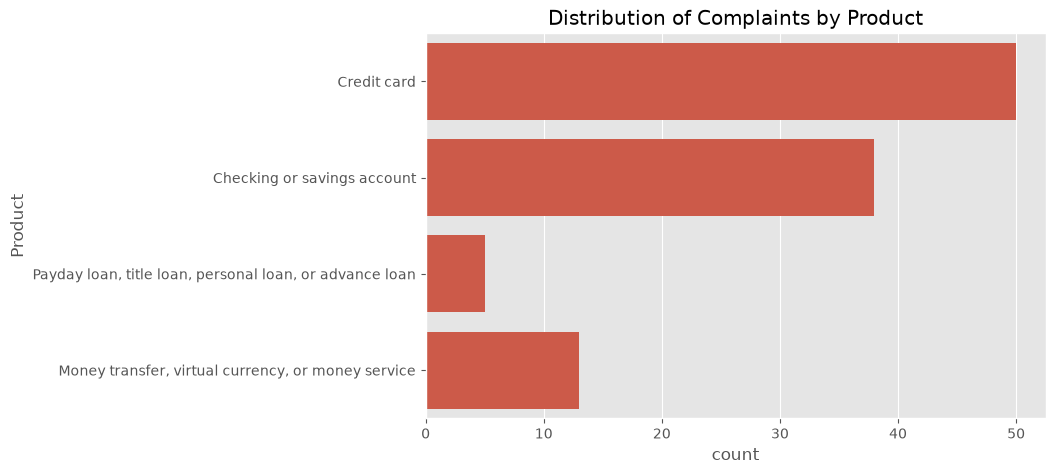

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=filtered_sample,
    y="Product"
)

plt.title("Distribution of Complaints by Product")
plt.show()

In [ ]:
plt.savefig("../data/processed/product_distribution.png")

<Figure size 640x480 with 0 Axes>

Narrative Length Distribution

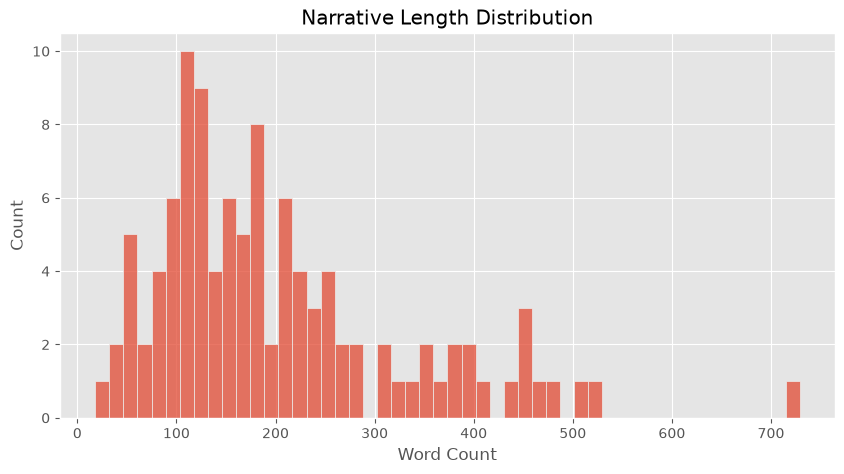

In [ ]:
filtered_sample["word_count"] = (
    filtered_sample["Consumer complaint narrative"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

plt.figure(figsize=(10,5))

sns.histplot(
    filtered_sample["word_count"],
    bins=50
)

plt.title("Narrative Length Distribution")
plt.xlabel("Word Count")
plt.show()

In [ ]:
plt.savefig("../data/processed/narrative_length_distribution.png")

<Figure size 640x480 with 0 Axes>

Generate Summary Statistics

In [ ]:
print("Dataset Shape:", filtered_sample.shape)

print("\nMissing Narratives:")
print(filtered_sample["Consumer complaint narrative"].isna().sum())

print("\nProduct Distribution:")
print(filtered_sample["Product"].value_counts())

print("\nNarrative Length Statistics:")
print(filtered_sample["word_count"].describe())

Dataset Shape: (106, 20)

Missing Narratives:
0

Product Distribution:
Product
Credit card                                                50
Checking or savings account                                38
Money transfer, virtual currency, or money service         13
Payday loan, title loan, personal loan, or advance loan     5
Name: count, dtype: int64

Narrative Length Statistics:
count    106.000000
mean     203.330189
std      128.861588
min       18.000000
25%      113.250000
50%      171.000000
75%      253.750000
max      729.000000
Name: word_count, dtype: float64
